# Training Neural Network in PyTorch

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)

### First we will train a linear regression model in PyTorch to demostrate how training a model looks like in PyTorch

Text(0, 0.5, 'y')

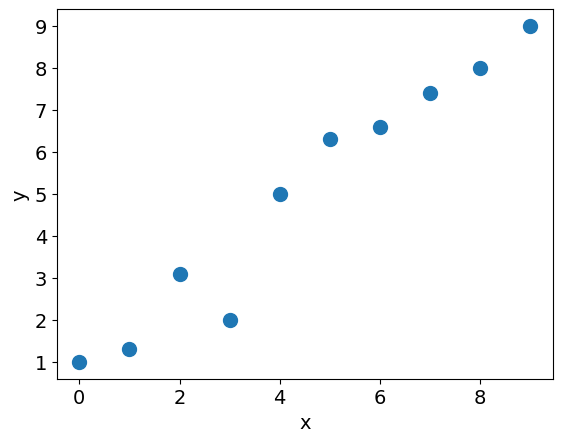

In [ ]:
X_train = np.arange(10, dtype='float32').reshape((10, 1))
y_train = np.array([1.0, 1.3, 3.1, 2.0, 5.0, 6.3, 6.6,
                    7.4, 8.0, 9.0], dtype='float32')

plt.plot(X_train, y_train, 'o', markersize=10)
plt.xlabel('x')
plt.ylabel('y')

### Use dataloader object to create training dataset and batches

In [ ]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

#Feature scaling (very important)
X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)

#Convert features from numpy to torch.tensor
X_train_norm = torch.from_numpy(X_train_norm)

#Convert labels from numpy to torch.tensor
y_train = torch.from_numpy(y_train)

#combine them together using dataset object
train_ds = TensorDataset(X_train_norm, y_train)

batch_size = 1 # We take the whole dataset together

#create dataloader object
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

### Train the model using torch.nn

In [ ]:
import torch.nn as nn

#number of epochs and learning rate
num_epochs = 100
learning_rate = 0.001

#define input and output shapes
input_size = 1
output_size = 1

#define the model (here a linear function)
model = nn.Linear(input_size, output_size)

#define the loss function (here Mean Squared Error)
loss_fn = nn.MSELoss(reduction='mean')

#define the optimizer (here Stochastic Gradient Descent)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        # 1. Generate predictions
        pred = model(x_batch)[:, 0]

        # 2. Calculate loss
        loss = loss_fn(pred, y_batch)

        # 3. Compute gradients
        loss.backward()

        # 4. Update parameters using gradients
        optimizer.step()

        # 5. Reset the gradients to zero
        optimizer.zero_grad()

    print(f'Epoch {epoch}  Loss {loss.item():.4f}')

Epoch 0  Loss 42.8594
Epoch 1  Loss 35.4190
Epoch 2  Loss 5.5493
Epoch 3  Loss 32.7236
Epoch 4  Loss 0.3277
Epoch 5  Loss 13.8579
Epoch 6  Loss 0.4015
Epoch 7  Loss 0.6914
Epoch 8  Loss 21.4383
Epoch 9  Loss 25.8130
Epoch 10  Loss 24.8131
Epoch 11  Loss 19.0552
Epoch 12  Loss 4.0674
Epoch 13  Loss 0.2522
Epoch 14  Loss 0.2689
Epoch 15  Loss 0.2189
Epoch 16  Loss 19.5824
Epoch 17  Loss 9.2077
Epoch 18  Loss 18.0980
Epoch 19  Loss 17.3990
Epoch 20  Loss 0.0802
Epoch 21  Loss 0.0609
Epoch 22  Loss 3.0257
Epoch 23  Loss 12.1396
Epoch 24  Loss 20.3545
Epoch 25  Loss 11.2614
Epoch 26  Loss 0.0911
Epoch 27  Loss 10.4488
Epoch 28  Loss 6.4187
Epoch 29  Loss 2.4825
Epoch 30  Loss 10.5973
Epoch 31  Loss 0.0066
Epoch 32  Loss 5.6504
Epoch 33  Loss 5.4750
Epoch 34  Loss 0.0281
Epoch 35  Loss 0.1891
Epoch 36  Loss 0.0322
Epoch 37  Loss 8.5870
Epoch 38  Loss 4.6863
Epoch 39  Loss 1.8998
Epoch 40  Loss 7.9554
Epoch 41  Loss 0.0161
Epoch 42  Loss 1.7597
Epoch 43  Loss 0.0115
Epoch 44  Loss 0.0096
Epoc

### Print and plot the model

Final Parameters: 2.3883955478668213 4.425774574279785


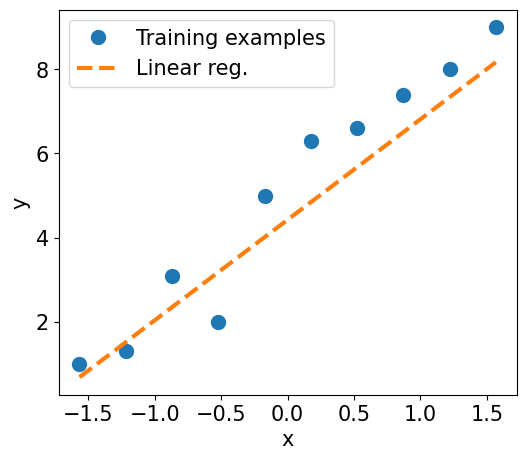

In [ ]:
print('Final Parameters:', model.weight.item(), model.bias.item())

X_test = np.linspace(0, 9, num=100, dtype='float32').reshape(-1, 1)
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm)
y_pred = model(X_test_norm)


fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1)
plt.plot(X_train_norm.detach().numpy(), y_train.detach().numpy(), 'o', markersize=10)
plt.plot(X_test_norm.detach().numpy(), y_pred.detach().numpy(), '--', lw=3)
plt.legend(['Training examples', 'Linear reg.'], fontsize=15)
ax.set_xlabel('x', size=15)
ax.set_ylabel('y', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)

### Now create a neural network function to replace the linear part of the model

In [ ]:
class Model(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size1)
        self.layer2 = nn.Linear(hidden_size1, hidden_size2)
        self.layer3 = nn.Linear(hidden_size2, output_size)

    def forward(self, x):
        x = self.layer1(x)
        x = nn.Tanh()(x)
        x = self.layer2(x)
        x = nn.Tanh()(x)
        x = self.layer3(x)
        return x

In [ ]:
#number of epochs and learning rate
num_epochs = 100
learning_rate = 0.001

#define input and output shapes
input_size = 1
output_size = 1

#define the model (here a linear function)
model = Model(input_size, 5, 5, output_size)

#define the loss function (here Mean Squared Error)
loss_fn = nn.MSELoss(reduction='mean')

#define the optimizer (here Stochastic Gradient Descent)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        # 1. Generate predictions
        pred = model(x_batch)[:, 0]

        # 2. Calculate loss
        loss = loss_fn(pred, y_batch)

        # 3. Compute gradients
        loss.backward()

        # 4. Update parameters using gradients
        optimizer.step()

        # 5. Reset the gradients to zero
        optimizer.zero_grad()

    print(f'Epoch {epoch}  Loss {loss.item():.4f}')

Epoch 0  Loss 25.6596
Epoch 1  Loss 23.4062
Epoch 2  Loss 8.0157
Epoch 3  Loss 19.1626
Epoch 4  Loss 17.1608
Epoch 5  Loss 0.3235
Epoch 6  Loss 0.0687
Epoch 7  Loss 0.2954
Epoch 8  Loss 47.7294
Epoch 9  Loss 2.0351
Epoch 10  Loss 0.0101
Epoch 11  Loss 1.1227
Epoch 12  Loss 12.1996
Epoch 13  Loss 0.4481
Epoch 14  Loss 9.6107
Epoch 15  Loss 0.6557
Epoch 16  Loss 13.1495
Epoch 17  Loss 0.0509
Epoch 18  Loss 0.8569
Epoch 19  Loss 1.4612
Epoch 20  Loss 1.5534
Epoch 21  Loss 4.7063
Epoch 22  Loss 17.7181
Epoch 23  Loss 3.2800
Epoch 24  Loss 0.4766
Epoch 25  Loss 0.4191
Epoch 26  Loss 1.2678
Epoch 27  Loss 0.0236
Epoch 28  Loss 4.3021
Epoch 29  Loss 0.1111
Epoch 30  Loss 5.7556
Epoch 31  Loss 0.0485
Epoch 32  Loss 4.7701
Epoch 33  Loss 0.0001
Epoch 34  Loss 0.0005
Epoch 35  Loss 0.7530
Epoch 36  Loss 0.6599
Epoch 37  Loss 0.1505
Epoch 38  Loss 3.2728
Epoch 39  Loss 0.4411
Epoch 40  Loss 0.3469
Epoch 41  Loss 6.6558
Epoch 42  Loss 0.3835
Epoch 43  Loss 0.4162
Epoch 44  Loss 0.1622
Epoch 45  Lo

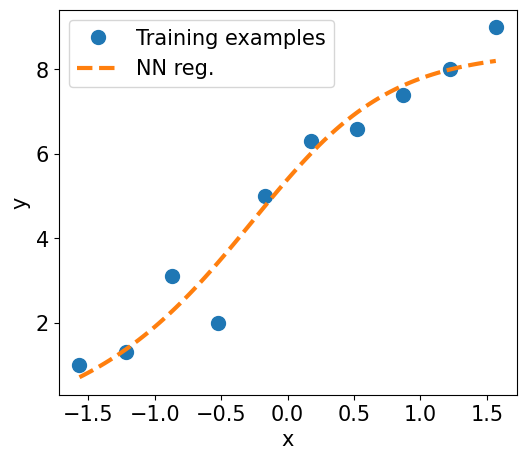

In [ ]:
X_test = np.linspace(0, 9, num=100, dtype='float32').reshape(-1, 1)
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm)
y_pred = model(X_test_norm)


fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1)
plt.plot(X_train_norm.detach().numpy(), y_train.detach().numpy(), 'o', markersize=10)
plt.plot(X_test_norm.detach().numpy(), y_pred.detach().numpy(), '--', lw=3)
plt.legend(['Training examples', 'NN reg.'], fontsize=15)
ax.set_xlabel('x', size=15)
ax.set_ylabel('y', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)

In [ ]:
model

Model(
  (layer1): Linear(in_features=1, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=5, bias=True)
  (layer3): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
!pip install torchlens
import torchlens as tl

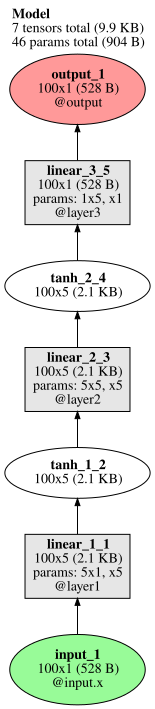

In [ ]:
model_history = tl.log_forward_pass(model, X_test_norm, layers_to_save='all', vis_opt='rolled')

In [ ]:
!pip install torchviz
from torchviz import make_dot

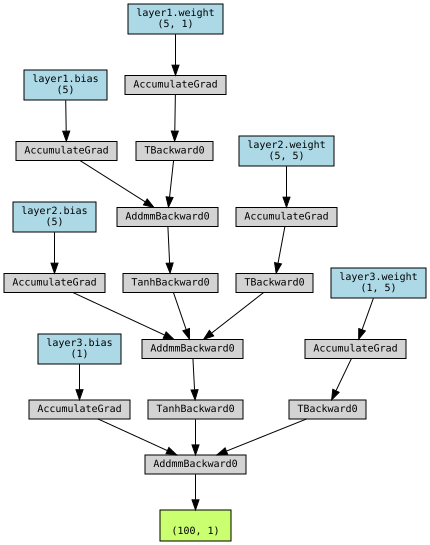

In [ ]:
make_dot(y_pred, params=dict(list(model.named_parameters())))

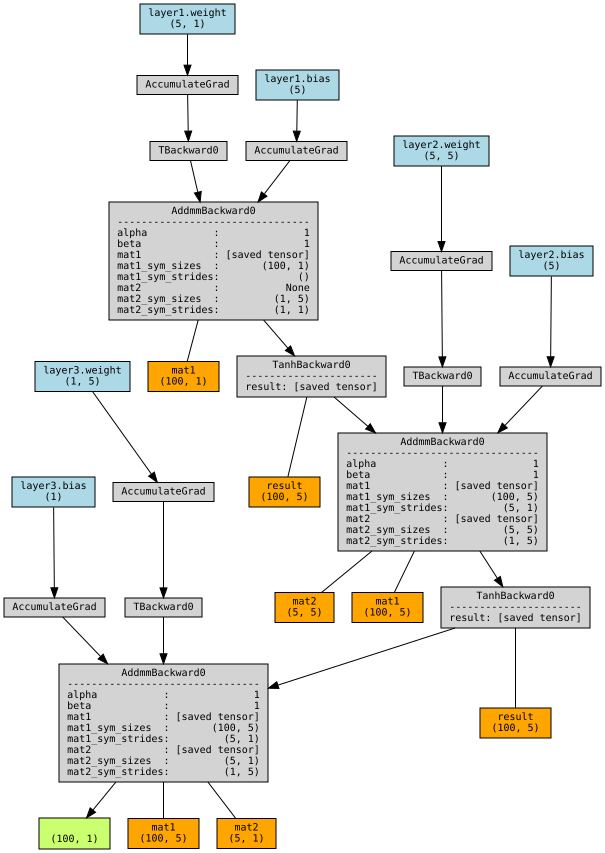

In [ ]:
make_dot(y_pred, params=dict(list(model.named_parameters())), show_attrs=True, show_saved=True)

### Custom Loss function

In [ ]:
def my_loss_fn(y_pred, y_target):
  return (y_pred - y_target).pow(2).mean()

In [ ]:
#number of epochs and learning rate
num_epochs = 100
learning_rate = 0.001

#define input and output shapes
input_size = 1
output_size = 1

#define the model (here a linear function)
model = Model(input_size, 85, 85, output_size)

#define the loss function (here Mean Squared Error)
#loss_fn = nn.MSELoss(reduction='mean')

#define the optimizer (here Stochastic Gradient Descent)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        # 1. Generate predictions
        pred = model(x_batch)[:, 0]

        # 2. Calculate loss
        loss = my_loss_fn(pred, y_batch)

        # 3. Compute gradients
        loss.backward()

        # 4. Update parameters using gradients
        optimizer.step()

        # 5. Reset the gradients to zero
        optimizer.zero_grad()

    print(f'Epoch {epoch}  Loss {loss.item():.4f}')

Epoch 0  Loss 48.1516
Epoch 1  Loss 18.0828
Epoch 2  Loss 17.6473
Epoch 3  Loss 0.1250
Epoch 4  Loss 0.5664
Epoch 5  Loss 2.3910
Epoch 6  Loss 0.0003
Epoch 7  Loss 0.0030
Epoch 8  Loss 0.4807
Epoch 9  Loss 0.2783
Epoch 10  Loss 4.5325
Epoch 11  Loss 0.2032
Epoch 12  Loss 1.8327
Epoch 13  Loss 0.1703
Epoch 14  Loss 0.0018
Epoch 15  Loss 1.2948
Epoch 16  Loss 0.0718
Epoch 17  Loss 1.1628
Epoch 18  Loss 1.5413
Epoch 19  Loss 0.0753
Epoch 20  Loss 1.3809
Epoch 21  Loss 0.0078
Epoch 22  Loss 4.0278
Epoch 23  Loss 1.3088
Epoch 24  Loss 1.0030
Epoch 25  Loss 4.0584
Epoch 26  Loss 1.2933
Epoch 27  Loss 0.0138
Epoch 28  Loss 0.3850
Epoch 29  Loss 0.0110
Epoch 30  Loss 0.0072
Epoch 31  Loss 0.0010
Epoch 32  Loss 0.0250
Epoch 33  Loss 0.8496
Epoch 34  Loss 0.0474
Epoch 35  Loss 0.4581
Epoch 36  Loss 1.0355
Epoch 37  Loss 0.9800
Epoch 38  Loss 0.7455
Epoch 39  Loss 0.6974
Epoch 40  Loss 0.0619
Epoch 41  Loss 0.9659
Epoch 42  Loss 0.0003
Epoch 43  Loss 0.6466
Epoch 44  Loss 0.0185
Epoch 45  Loss 0.

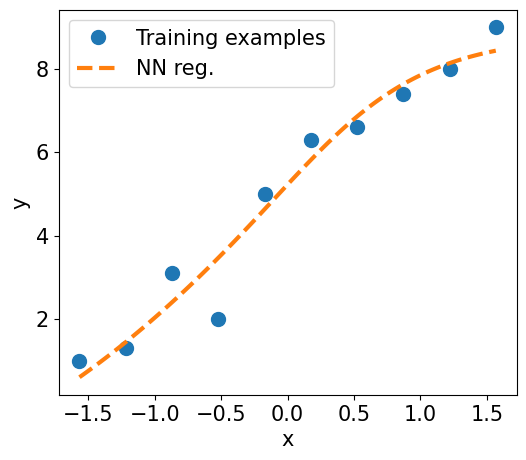

In [ ]:
X_test = np.linspace(0, 9, num=100, dtype='float32').reshape(-1, 1)
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm)
y_pred = model(X_test_norm)


fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1)
plt.plot(X_train_norm.detach().numpy(), y_train.detach().numpy(), 'o', markersize=10)
plt.plot(X_test_norm.detach().numpy(), y_pred.detach().numpy(), '--', lw=3)
plt.legend(['Training examples', 'NN reg.'], fontsize=15)
ax.set_xlabel('x', size=15)
ax.set_ylabel('y', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)